In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

import pickle

In [2]:
data = pd.read_excel("World_development_mesurement.xlsx")

data.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [3]:
data.info()

data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

,Birth Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,Health Exp % GDP,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban
count,2585.000000,2.125000e+03,1718.000000,185.000000,1.785000e+03,2395.000000,1416.000000,2444.000000,2531.000000,1880.000000,2568.000000,2568.000000,2537.000000,2704.0,2484.000000,2484.000000,2484.000000,2.704000e+03,2678.000000
mean,0.022715,1.423071e+05,39.999418,94.875676,7.723684e+04,0.064170,302.068503,0.032813,0.239747,0.148103,71.159268,66.461838,0.578124,1.0,0.303051,0.623481,0.073465,3.145729e+07,0.562953
std,0.011338,6.159288e+05,57.318588,54.791906,2.599239e+05,0.026325,273.299686,0.029968,0.260132,0.171829,10.708262,9.390217,0.474647,0.0,0.106577,0.069660,0.049541,1.242894e+08,0.245897
min,0.007000,7.000000e+00,1.000000,1.000000,8.000000e+00,0.008000,12.000000,0.002000,0.000000,0.005000,39.000000,37.000000,0.000000,1.0,0.118000,0.474000,0.003000,1.887600e+04,0.082000
25%,0.013000,1.360000e+03,13.000000,48.000000,3.737000e+03,0.046000,156.000000,0.009000,0.000000,0.080000,64.000000,61.000000,0.100000,1.0,0.204750,0.559000,0.033000,8.783360e+05,0.356000
50%,0.020000,8.529000e+03,26.000000,94.000000,1.433800e+04,0.061000,239.000000,0.020000,0.100000,0.120000,75.000000,69.000000,0.500000,1.0,0.299500,0.642500,0.052000,5.800324e+06,0.560000
75%,0.031000,5.910800e+04,45.000000,142.000000,4.185200e+04,0.079000,344.750000,0.053000,0.400000,0.173000,79.000000,73.250000,0.900000,1.0,0.402000,0.676000,0.112000,2.014089e+07,0.765000
max,0.053000,8.286892e+06,694.000000,189.000000,2.727728e+06,0.225000,2600.000000,0.141000,1.000000,4.965000,87.000000,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000


In [4]:
print(data.columns)

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')


In [5]:
# Save country column
country = data["Country"]

# Remove it from dataset for clustering
data = data.drop("Country", axis=1)

In [6]:
for col in data.columns:
    
    if data[col].dtype == "object":
        
        data[col] = data[col].astype(str).str.replace('%','')
        data[col] = data[col].str.replace('$','')
        data[col] = data[col].str.replace(',','')
        
        try:
            data[col] = pd.to_numeric(data[col])
        except:
            pass

C:\Users\Srihan\AppData\Local\Temp\ipykernel_10400\265219545.py:6: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  data[col] = data[col].str.replace('$','')


In [7]:
data = data.fillna(data.median(numeric_only=True))

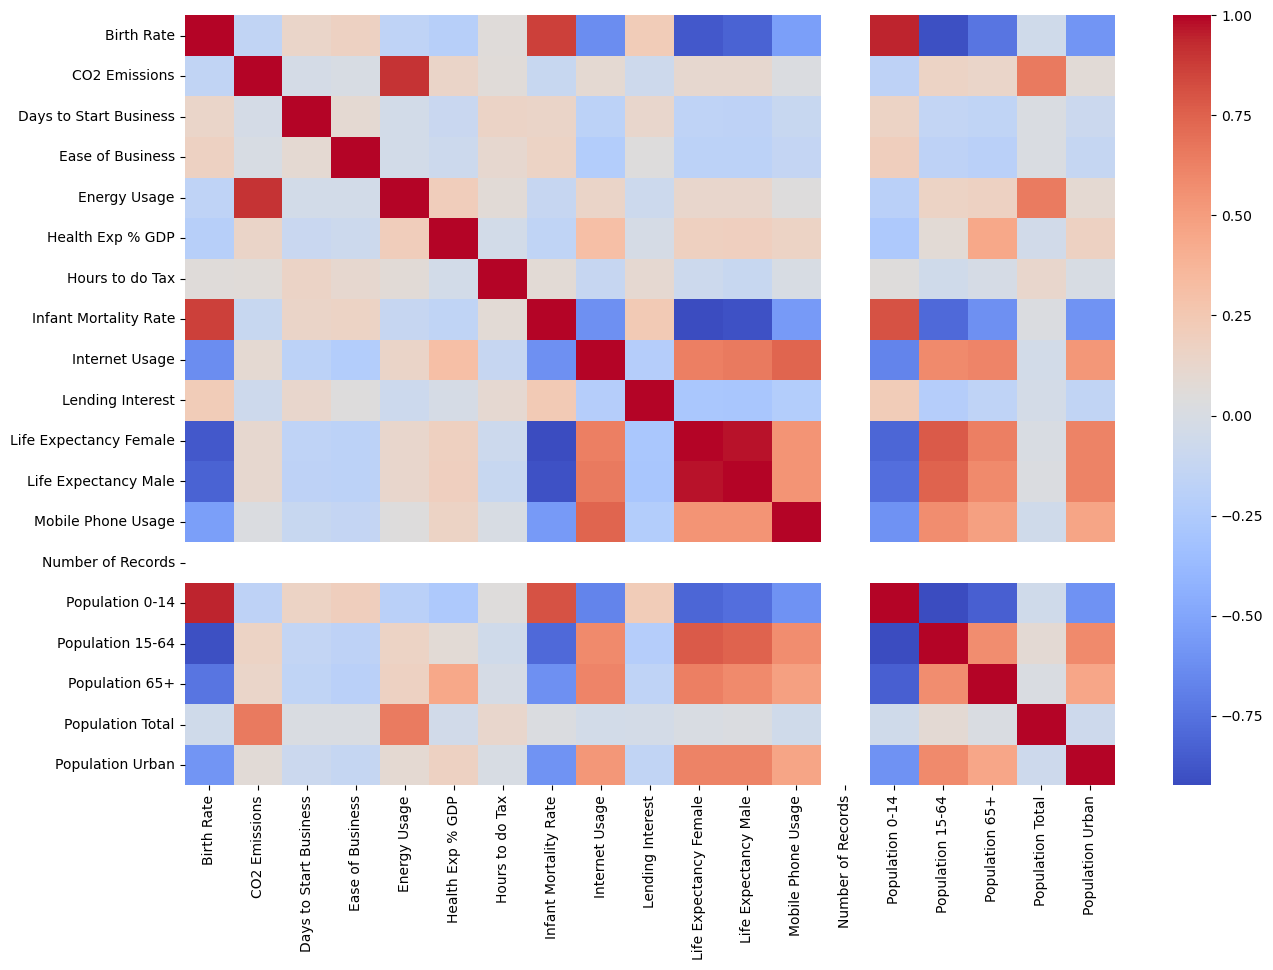

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm")

plt.show()

In [9]:
data = data.apply(pd.to_numeric, errors='coerce')

In [10]:
data = data.fillna(data.median())

In [11]:
import numpy as np

data = data.replace([np.inf, -np.inf], np.nan)

data = data.fillna(data.median())

In [12]:
print(data.isnull().sum())

Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Days to Start Business    0
Ease of Business          0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Number of Records         0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

In [14]:
print(data.isnull().sum())

Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Days to Start Business    0
Ease of Business          0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Number of Records         0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64


In [15]:
from sklearn.decomposition import PCA
pca=PCA(n_components=0.9)
x_pca=pca.fit_transform(scaled_data)
print(x_pca.shape)

(2704, 11)


In [16]:
explained_variance=pca.explained_variance_ratio_
print("Explained variance ratio:",explained_variance)
print("Total variance covered:",np.sum(explained_variance))

Explained variance ratio: [0.37399241 0.17196794 0.07037986 0.0545047  0.04280894 0.04141713
 0.03820013 0.03327491 0.03256634 0.02880622 0.02362442]
Total variance covered: 0.9115429894171277


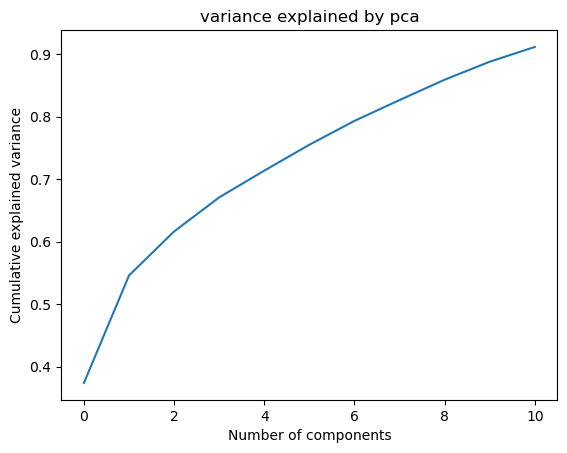

In [17]:
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("variance explained by pca")
plt.show()

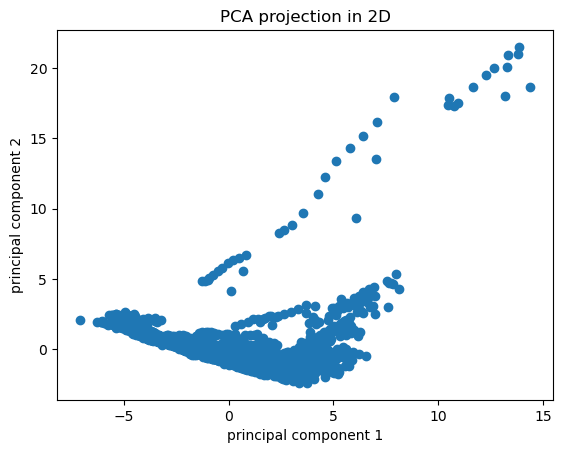

In [18]:
plt.scatter(x_pca[:,0],x_pca[:,1])
plt.xlabel("principal component 1")
plt.ylabel("principal component 2")
plt.title("PCA projection in 2D")
plt.show()

In [20]:
print("original features:",scaled_data.shape[1])
print("reduced features:",x_pca.shape[1])

original features: 24
reduced features: 11


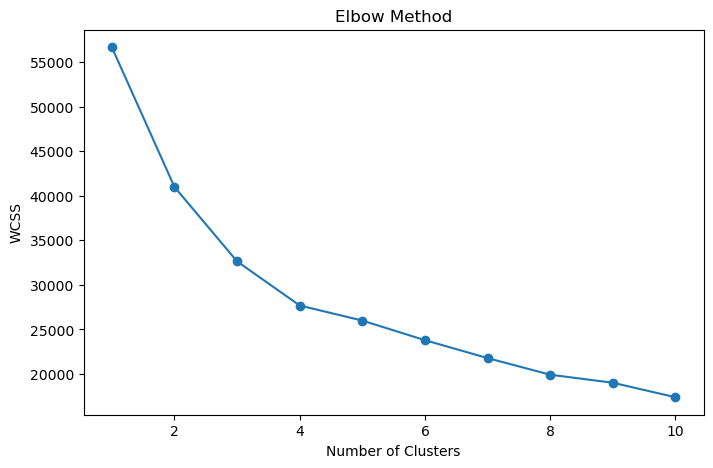

In [21]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(x_pca)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(x_pca)

data["Cluster_KMeans"] = kmeans_labels

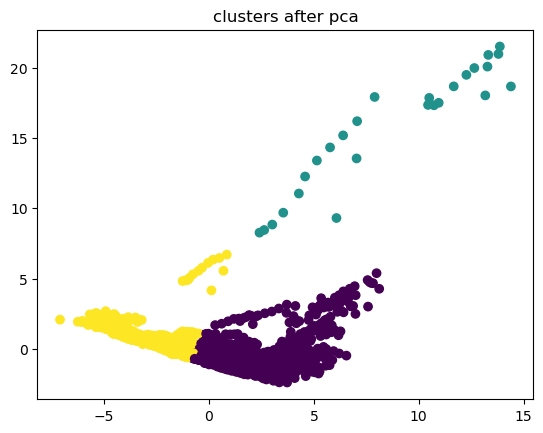

In [23]:
plt.scatter(x_pca[:,0],x_pca[:,1],c=kmeans_labels)
plt.title("clusters after pca")
plt.show()

In [24]:
data["Cluster_KMeans"].value_counts()

0    1631
2    1047
1      26
Name: Cluster_KMeans, dtype: int64

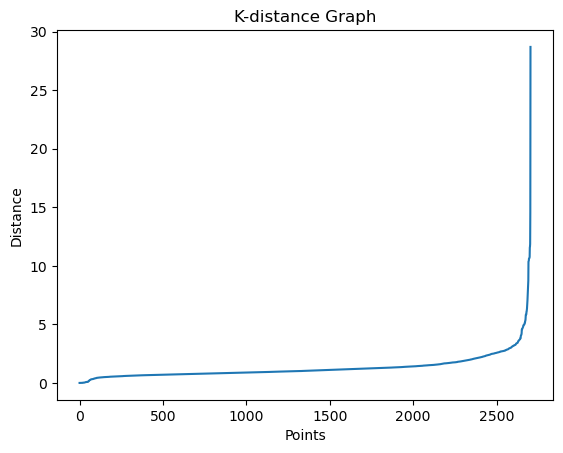

In [27]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(x_pca)
distances, indices = neighbors_fit.kneighbors(x_pca)
distances = np.sort(distances[:,9]) 
plt.plot(distances)
plt.xlabel("Points")
plt.ylabel("Distance")
plt.title("K-distance Graph")
plt.show()

In [29]:
from sklearn.cluster import DBSCAN
eps_vals=[1.0,1.2,1.3,1.4,1.5,1.7,1.9,2.0]
min_sample_range=range(1,20)
output=[]
for eps_val in eps_vals:
    for min_samp in min_sample_range:
        dbscan_label=DBSCAN(eps=eps_val,min_samples=min_samp).fit(x_pca).labels_
        score = silhouette_score(x_pca, dbscan_label)
        output.append([eps_val, min_samp, score])
        print(f"  eps={eps_val}, min_samples={min_samp}, score={score:.4f}")


  eps=1.0, min_samples=1, score=-0.2749
  eps=1.0, min_samples=2, score=-0.2954
  eps=1.0, min_samples=3, score=-0.2975
  eps=1.0, min_samples=4, score=-0.3197
  eps=1.0, min_samples=5, score=-0.3472
  eps=1.0, min_samples=6, score=-0.3772
  eps=1.0, min_samples=7, score=-0.4059
  eps=1.0, min_samples=8, score=-0.3633
  eps=1.0, min_samples=9, score=-0.1366
  eps=1.0, min_samples=10, score=-0.1320
  eps=1.0, min_samples=11, score=0.0239
  eps=1.0, min_samples=12, score=0.0191
  eps=1.0, min_samples=13, score=0.0164
  eps=1.0, min_samples=14, score=0.1001
  eps=1.0, min_samples=15, score=0.0937
  eps=1.0, min_samples=16, score=0.0903
  eps=1.0, min_samples=17, score=0.0870
  eps=1.0, min_samples=18, score=0.0854
  eps=1.0, min_samples=19, score=0.0768
  eps=1.2, min_samples=1, score=-0.2608
  eps=1.2, min_samples=2, score=-0.2611
  eps=1.2, min_samples=3, score=-0.2463
  eps=1.2, min_samples=4, score=-0.2481
  eps=1.2, min_samples=5, score=-0.2816
  eps=1.2, min_samples=6, score=-0.3096

In [30]:
output_sorted = sorted(output, reverse=True, key=lambda x: x[2])
best_eps, best_min_samples, best_score = output_sorted[0]
print(f"\n Best parameters: eps={best_eps}, min_samples={best_min_samples}, score={best_score:.4f}")


✓ Best parameters: eps=2.0, min_samples=16, score=0.4174


In [32]:
df_results = pd.DataFrame(output, columns=['eps', 'min_samples', 'score'])

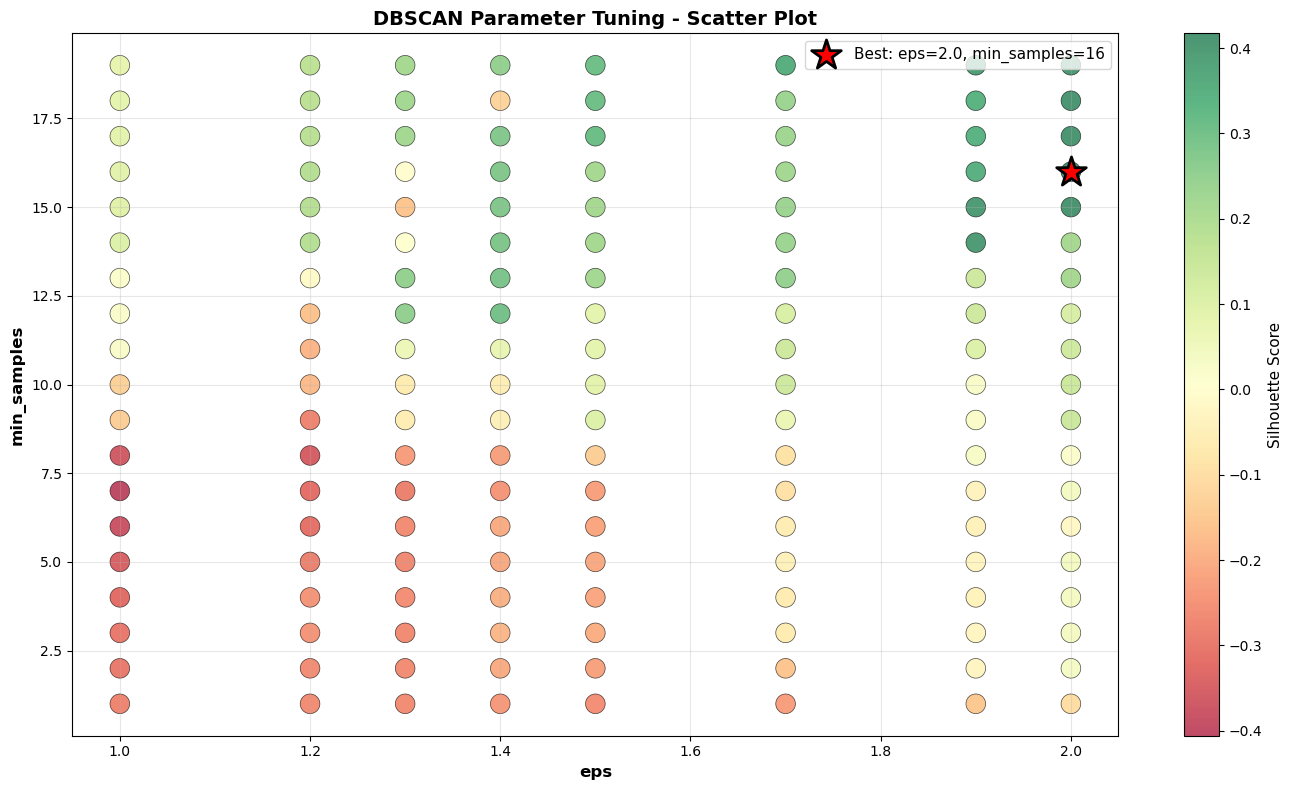

In [33]:
plt.figure(figsize=(14, 8))

scatter = plt.scatter(df_results['eps'], df_results['min_samples'], 
                     c=df_results['score'], cmap='RdYlGn', 
                     s=200, alpha=0.7, edgecolors='black', linewidth=0.5)

# Highlight best point
plt.scatter([best_eps], [best_min_samples], 
           color='red', s=500, marker='*', 
           edgecolors='black', linewidth=2,
           label=f'Best: eps={best_eps}, min_samples={best_min_samples}', zorder=5)

plt.xlabel('eps', fontsize=12, fontweight='bold')
plt.ylabel('min_samples', fontsize=12, fontweight='bold')
plt.title('DBSCAN Parameter Tuning - Scatter Plot', fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter)
cbar.set_label('Silhouette Score', fontsize=11)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('GRAPH_4_scatter_plot.png', dpi=100, bbox_inches='tight')
plt.show()

In [34]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=2.0, min_samples=16)
dbscan_labels = dbscan.fit_predict(x_pca)

In [35]:
data['Cluster_DBScan']=dbscan_labels

In [36]:
print(data['Cluster_DBScan'].value_counts())

 0    2391
-1     313
Name: Cluster_DBScan, dtype: int64


In [37]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(x_pca, kmeans_labels)

dbscan_score = silhouette_score(x_pca, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

print("KMeans Silhouette Score:", kmeans_score)

print("DBScan Silhouette Score:", dbscan_score)

KMeans Silhouette Score: 0.3427172110954737
DBScan Silhouette Score: 0.41736582124386046


In [38]:
data["Country"] = country
data.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,Cluster_KMeans,Cluster_DBScan,Country
0,0.020,41.0,87931.0,26.0,94.0,26998.0,5.479006e+10,0.035,60.0,239.0,...,0.342,0.619,0.039,31719449,0.599,102000000.0,193000000.0,2,0,Algeria
1,0.050,41.0,9542.0,26.0,94.0,7499.0,9.129595e+09,0.034,22.0,239.0,...,0.476,0.499,0.025,13924930,0.324,34000000.0,146000000.0,2,-1,Angola
2,0.043,41.0,1617.0,26.0,94.0,1983.0,2.359122e+09,0.043,15.0,239.0,...,0.454,0.517,0.029,6949366,0.383,77000000.0,50000000.0,2,0,Benin
3,0.027,41.0,4276.0,26.0,94.0,1836.0,5.788312e+09,0.047,152.0,239.0,...,0.383,0.587,0.029,1755375,0.532,227000000.0,209000000.0,2,0,Botswana
4,0.046,41.0,1041.0,26.0,94.0,14338.0,2.610959e+09,0.051,12.0,239.0,...,0.468,0.505,0.028,11607944,0.178,23000000.0,30000000.0,2,0,Burkina Faso


In [39]:
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)
with open("dbscan_model.pkl","wb") as f:
    pickle.dump(dbscan,f)
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)
with open("pca.pkl","wb") as f:
    pickle.dump(pca,f)